In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.float_format', '{:.2f}'.format)

cust = pd.read_csv('../cust_data.csv')

cust_fix = cust.copy()

cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,N,1860.00,1716.00,0.00,N
8224,C,F,15.00,1,N,Y,1296.10,194.41,643.10,N
8225,G,M,12.00,1,N,N,13799.67,2069.95,10605.93,N
8226,C,F,40.00,0,N,N,3140.00,942.00,1884.00,Y


In [3]:
# 실습을 위한 cust 데이터프레임 복사
cust = cust_fix.copy()

In [31]:
# 이상치 처리하기
    # 특정 추세에서 크게 벗어난 데이터, 중앙값을 크게 벗어난 데이터를 의미
    # 삭제 또는 대체값으로 처리

## 1. 범주형 데이터일 경우 #####################################
    # value_counts로 값의 분포와 함께 Trash 값이 있는지 확인 가능
cust['sex'].value_counts()
cust['npay'].value_counts()
cust['class'].value_counts()

# 만약 H Class가 이상치라면?
# 1. 데이터 제거하기
    # Boolean indexing을 활용해서 class 칼럼의 값이 H가 아닌 것만 추출
# isNotHClass = cust['class'] != 'H'
# cust = cust[isNotHClass]

# 2. 데이터 대체하기
    # replace 함수로 H에서 F로 변경
# cust['class'] = cust['class'].replace('H', 'F')
# cust['class'].value_counts()

class
D    2181
G    2038
C    1913
E    1244
F     852
Name: count, dtype: int64

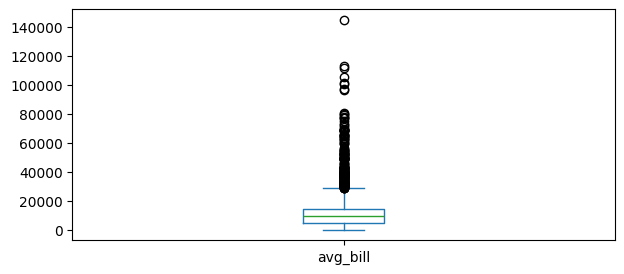

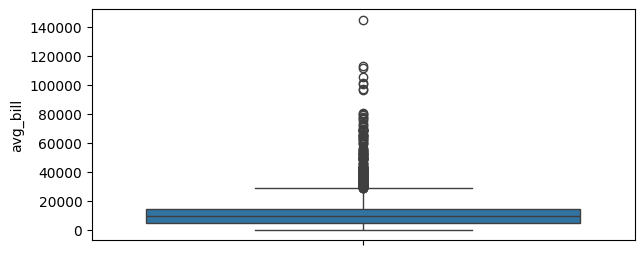

In [4]:
## 2. 연속형(숫자형) 데이터일 경우 #####################################
# 1. 이상치 컬럼 탐색
    # describe을 사용해서 연속형 컬럼에 대한 통계 정보를 알 수 있다. 결과로 나온 컬럼만 연속형 컬럼이다.
    # age, avg_bill 컬럼은 숫자 사이즈가 차이가 많이 나므로, 이상치 처리(스케일링) 필요
        # age 컬럼의 최소값 4, 최대값 144
        # avg_bill 컬럼의 최소값 299, 최대값 144739
cust.describe()

import matplotlib.pyplot as plt
plt.figure(figsize=(7,3)) # 가로 7, 세로 3 인치 figure 객체 생성
cust['avg_bill'].plot(kind='box') # avg_bill 컬럼을 boxplot 그래프 사용
plt.show() # 설정한 그래프 화면에 출력

import seaborn as sns
plt.figure(figsize=(7,3))
sns.boxplot(data=cust, y='avg_bill') # avg_bill 컬럼을 boxplot 그래프 사용
plt.show()

# 2. 해당 컬럼 이상치 확인하기
    # Outlier: Q1, Q3가 거리의 1.5배가 넘는 값
        # Upper Fence = Q3 + 1.5 * IQR
        # Lower Fence = Q1 - 1.5 * IQR
    # 기본적으로 이상치는 변경 및 제거하여 분석, 학습할 수 있으나, 때에 따라 제거 및 변경하지 않고 진행이 필요할 수 있다. (도메인 전문가와 협의 필요)

# 도메인 제거 함수 생성
def removeOutliers(df, column):
    # Q1, Q3 구하기
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    # IQR
    iqr = q3 - q1

    # 이상치가 아닌 정상값
    noOutlier = (df[column] < (q3 + 1.5 * iqr)) & (df[column] > (q1 - 1.5 * iqr))
    y = df[noOutlier]

    return y

# 이상치를 LF, UF로 변경하는 함수 생성
def changeOutliers(df, column):
    # Q1, Q3 구하기
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    # IQR
    iqr = q3 - q1

    # 이상치 발견 시 대체값 설정
    Min = 0
    if (q1 - 1.5 * iqr) > 0:
        Min = (q1 - 1.5 * iqr)
    Max = q3 + iqr

    # 이상치 변경
    df.loc[ (df[column] > Max), column ] = Max
    df.loc[ (df[column] < Min), column ] = Min

    return df

cust = removeOutliers(cust, 'avg_bill')
cust = removeOutliers(cust, 'A_bill')
cust = removeOutliers(cust, 'B_bill')
cust = changeOutliers(cust, 'avg_bill')
cust = changeOutliers(cust, 'A_bill')
cust = changeOutliers(cust, 'B_bill')
# cust.describe()

In [ ]:
# Feature Engineering
    # 모델 정확도를 높이기 위해 주어진 데이터를 잘 표현할 수 있는 Features로 변형시키는 과정
    # 데이터의 도메인 지식을 활용해 Features를 만든다.

## 1. Binning #############################################
    # 자료를 일정 규격의 통에 넣는 것
    # 연속형 데이터를 범위를 나누어 범주형 데이터로 변환하는 과정
    # 예시: age 컬럼으로 by_age(나이대) 새로 만들기

cust['by_age'] = (cust['age'] // 10) * 10
cust = cust.astype({'by_age':int})

# cut
    # 사용자가 구간을 지정하여 쉽게 범주화 가능
    # 연속형 데이터를 구간으로 나누어 범주화하고 범주마다 Label로 지정
    # 예시: avg_bill을 3개 구간으로 나누어 bill_rating 컬럼에 표현하기
q1 = cust['avg_bill'].quantile(0.25)
q3 = cust['avg_bill'].quantile(0.75)
print(q1, q3)

cust['bill_rating'] = pd.cut(cust['avg_bill'],
                             bins=[0, q1, q3, cust['avg_bill'].max()],
                             labels=['low', 'mid', 'high']
                             )

# qcut
    # cut과 유사하지만 구간의 개수를 주면 스스로 같은 크기로 구간을 나눠줌
    # 예시: avg_bill을 3개의 동일 구간으로 나누어 bill_rating 컬럼에 표현하기
cust['bill_rating'] = pd.qcut(cust['avg_bill'],
                              3,
                              labels=['low', 'mid', 'high']
                              )

# 확인 결과
cust.head()
cust['bill_rating'].value_counts()

## 2. Scaling #############################################
    # 숫자 데이터를 비슷한 레벨의 크기로 고르게 맞추는 과정
    # 각 컬럼에 있는 데이터의 상대적 크기에 따라 분석 및 모델링 결과가 달라질 수 있다.
    # 0 ~ 1000까지 값을 갖는 변수 A와 0~10까지 값을 갖는 변수 B가 있다면 A에 영향을 크게 받는다.
    # 방법: 표준화, 정규화

# 예시
    # describe로 컬럼의 숫자 범위 확인
    # avg_bill, age 2개의 숫자형 컬럼의 숫자 범위 차이가 크다는 점을 확인
        # avg_bill: mean=9809, std=6242, max=28322
        # age: mean=47, std=19, max=104
cust.describe()
cust_bill_age = cust[['avg_bill', 'age']]

# 1. Standardization
    # 표준화 = (x - mean) / std
    # avg_bill 컬럼과 age 컬럼의 값을 스케일링
# cust_standardization = (cust_bill_age - cust_bill_age.mean()) / cust_bill_age.std()
# cust_standardization.head()
# cust_standardization.describe()

# 2. Normalization
    # 정규화 = (x - min) / (max - min)
cust_normalization = (cust_bill_age - cust_bill_age.min()) / (cust_bill_age.max() - cust_bill_age.min())
    # sklearn의 MinMaxScaler 함수 사용
        # MinMaxScaler 수행하면 컬럼의 값이 0 ~ 1 사이의 값으로 변한다.
# cust_normalization = cust_bill_age.copy()
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# cust_normalization[:] = scaler.fit_transform(cust_normalization[:])
cust_normalization.head()
cust_normalization.describe()


## 3. Label Encording #############################################
    # 범주형 컬럼의 값을 숫자로 매핑해주는 작업 과정을 의미
    # 컴퓨터가 이해하기 쉽도록 숫자가 아닌 데이터(예: 문자열 데이터)를 숫자로 표현하기
    # 예시: 성별은 M, F -> F는 0, M는 1로 맵핑하는 과정

# 예시
    # 등급, 성별, 나이 컬럼을 라벨 인코딩 실시
cust_class_sex_age = cust[['class', 'sex', 'age']]
cust_class_sex_age.head()

# 1. replace 함수 사용하기
cust_replace_func = cust_class_sex_age['sex'].replace({ 'F':0, 'M':1 })
cust_replace_func.head()

# 2. sklearn의 LabelEncoder 함수 사용하기
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cust_class_sex_age['sex'] = le.fit_transform(cust_class_sex_age['sex'])
cust_class_sex_age.head()

## 4. One-Hot Encording #############################################
    # 순서가 있는 문자열 칼럼은 Label Encoding으로 매핑하면 된다.
    # 하지만 순서가 없는 문자열이라면, 의도하지 않게 우선순위가 매겨지는 문제가 발생
    # 이런 문제점을 해결하기 위해 같은 위치에서 문자열을 숫자로 매핑하는 과정이 원핫 인코딩
    # 예시: color 컬럼은 red, green, blue가 있을 때 순서가 필요 없다.
        # red:100, green:010, blue:001 로 표현 가능
    # 예시: class가 순서가 필요없을 경우

# pandas의 get_dummies 함수
pd.get_dummies(data=cust_class_sex_age, columns=['class']).head()


## 5. PCA(Principle Component Analysis), 차원축소 #############################################
    # 데이터의 차원(특성의 수)을 줄여서 데이터의 중요한 정보를 최대한 보존하는 과정
    # 핵심 원리는 데이터의 분산을 최대화하는 주성분을 찾는 것이다.
        # 분산은 데이터가 특정 방향으로 퍼져있는 정도를 나타내며
        # 큰 분산은 해당 방향에 주요 정보나 패턴이 포함되어 있음을 의미함.

# 데이터 호출 (seaborn의 iris 붓꽃데이터)
iris = sns.load_dataset('iris')
iris.iloc[:, :-1] # species빼고 나머지 출력

# PCA로 차원 축소 실행
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 컬럼의 개수 = 차원의 개수, 기존 iris의 4개의 차원에서 2개의 차원으로 축소
pca_comp = pca.fit_transform(iris.iloc[:, :-1])

# 저장 후 출력(확인)
df_pca = pd.DataFrame(data=pca_comp, columns=['PCA1', 'PCA2'])
df_pca['target'] = iris.species
df_pca

# explained_variance_ratio 속성
    # 2개의 주성분이 얼마나 원본 데이터의 변동성을 반영하는가
    # 0.92461872: 첫 번째 주성분은 92%의 데이터 변동성
    # 0.05306648: 두 번째 주성분은 5%의 데이터 변동성
    # 두 주성분의 변동성을 더해 95%의 데이터 변동성을 설명함
pca.explained_variance_ratio_

4435.2000275 13766.8167


array([0.92461872, 0.05306648])